In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Input,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import os

os.listdir("/kaggle/input")
DATASET_PATH = "/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray"

In [3]:
train_path = os.path.join(DATASET_PATH, "train")
test_path = os.path.join(DATASET_PATH, "test")

train_normal = len(os.listdir(os.path.join(train_path, "NORMAL")))
train_pneumonia = len(os.listdir(os.path.join(train_path, "PNEUMONIA")))

test_normal = len(os.listdir(os.path.join(test_path, "NORMAL")))
test_pneumonia = len(os.listdir(os.path.join(test_path, "PNEUMONIA")))

print(f"Training - Normal: {train_normal}")
print(f"Training - Pneumonia: {train_pneumonia}")

print(f"Testing - Normal: {test_normal}")
print(f"Testing - Pneumonia: {test_pneumonia}")

Training - Normal: 1349
Training - Pneumonia: 3883
Testing - Normal: 234
Testing - Pneumonia: 390


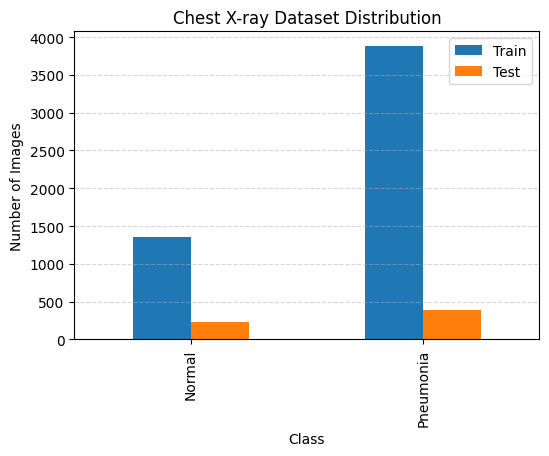

In [4]:
data = pd.DataFrame({
    "Class": ["Normal", "Pneumonia"],
    "Train": [train_normal, train_pneumonia],
    "Test": [test_normal, test_pneumonia]
})

data.set_index("Class").plot(kind="bar", figsize=(6,4))

plt.title("Chest X-ray Dataset Distribution")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

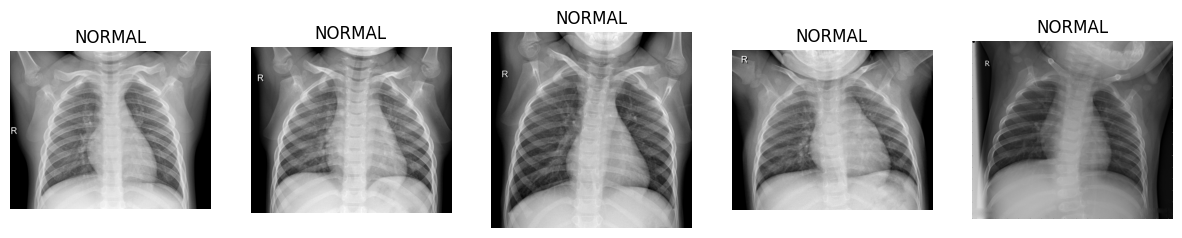

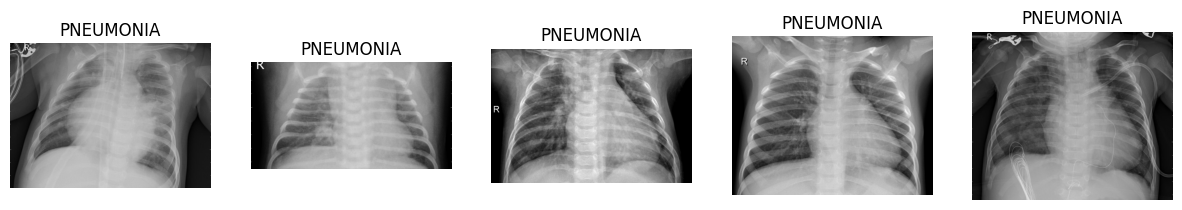

In [5]:
train_path = DATASET_PATH + "/train"

def show_images(class_name, n=5):
    folder = os.path.join(train_path, class_name)
    images = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))

        plt.subplot(1,n,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis("off")

    plt.show()

show_images("NORMAL")
show_images("PNEUMONIA")

In [6]:
# checking image dimentions.

sizes = []

for cls in ["NORMAL", "PNEUMONIA"]:
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder):
        img = Image.open(os.path.join(folder, img_name))
        sizes.append(img.size)

sizes[:10]

[(1550, 1059),
 (1584, 1237),
 (1654, 1259),
 (1114, 832),
 (2091, 2326),
 (1268, 924),
 (1426, 1128),
 (1936, 1669),
 (1322, 978),
 (1932, 1712)]

In [7]:
size_df = pd.DataFrame(sizes, columns=["Width","Height"])

size_df.describe()

,Width,Height
count,5232.000000,5232.000000
mean,1320.695336,968.181384
std,355.024600,378.542729
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1284.000000,888.000000
75%,1552.000000,1187.750000
max,2916.000000,2663.000000


In [8]:
modes = []

for cls in ["NORMAL","PNEUMONIA"]:
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder):
        img = Image.open(os.path.join(folder,img_name))
        modes.append(img.mode)

pd.Series(modes).value_counts()

L      4949
RGB     283
Name: count, dtype: int64

In [9]:
bad_images = []

for cls in ["NORMAL","PNEUMONIA"]:
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder):
        try:
            Image.open(os.path.join(folder,img_name)).verify()
        except:
            bad_images.append(img_name)

print("Corrupted Images:",len(bad_images))

Corrupted Images: 0


## Data Preprocessing

In [10]:
# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Performance Optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 5232 files belonging to 2 classes.
Using 4186 files for training.


I0000 00:00:1784917201.981662      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784917201.985171      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [11]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


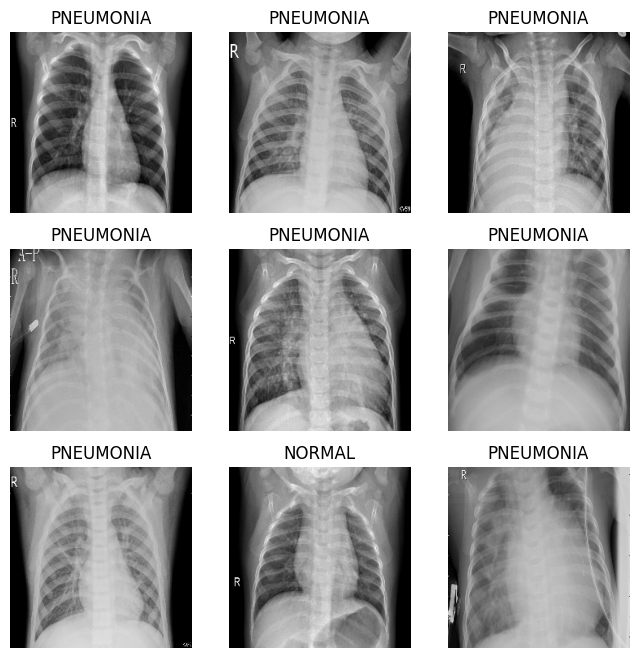

In [12]:
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [13]:
y_train = np.concatenate([labels.numpy() for _, labels in train_ds])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9061930783242258), 1: np.float64(0.6777849740932642)}


## Building CNN Model

In [14]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [15]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Input Layer
inputs = Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# MobileNetV2-specific preprocessing: raw [0,255] -> [-1,1]
x = preprocess_input(x)

# Pretrained MobileNetV2
x = base_model(x, training=False)

# Classification Head
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

# Final Model
model = Model(inputs=inputs, outputs=outputs)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Phase 1 : train the classification head (frozen MobileNetV2 backbone)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stopping],
    class_weight=class_weights
)

Epoch 1/15
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6821 - loss: 0.6023
Epoch 1: val_accuracy improved from None to 0.94264, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.7957 - loss: 0.4344 - val_accuracy: 0.9426 - val_loss: 0.1894
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9003 - loss: 0.2576
Epoch 2: val_accuracy improved from 0.94264 to 0.95029, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9064 - loss: 0.2391 - val_accuracy: 0.9503 - val_loss: 0.1533
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9125 - loss: 0.2022
Epoch 3: val_accuracy improved from 0.95029 to 0.95315, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9116 - loss: 0.2043 - val_

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")

y_true = np.concatenate([y for _, y in test_ds], axis=0)

y_pred = model.predict(test_ds)
y_pred = (y_pred > 0.5).astype(int).flatten()

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.8558 - loss: 0.3167
Test Accuracy: 0.8558
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step
              precision    recall  f1-score   support

           0       0.97      0.64      0.77       234
           1       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.86      0.85       624

[[149  85]
 [  5 385]]


## Fine Tuning : Phase 2
unfreeze the last 20 layers of mibileNet

In [21]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [22]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stopping],
    class_weight=class_weights
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8956 - loss: 0.4154
Epoch 1: val_accuracy did not improve from 0.95985
131/131 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9150 - loss: 0.2867 - val_accuracy: 0.9044 - val_loss: 0.2567
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9331 - loss: 0.1664
Epoch 2: val_accuracy did not improve from 0.95985
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9341 - loss: 0.1679 - val_accuracy: 0.9168 - val_loss: 0.2267
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9345 - loss: 0.1562
Epoch 3: val_accuracy did not improve from 0.95985
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9326 - loss: 0.1604 - val_accuracy: 0.9446 - val_loss: 0.1498
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9411 - loss: 0.1556
Epoch 4: val_accuracy did not improve from 0.95985
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9431 - loss: 0.1470 - val_accuracy

In [24]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

y_pred = model.predict(test_ds)
y_pred = (y_pred > 0.5).astype(int).flatten()

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8814 - loss: 0.3725
Test Loss: 0.3725
Test Accuracy: 0.8814
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step
              precision    recall  f1-score   support

           0       0.97      0.71      0.82       234
           1       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.85      0.86       624
weighted avg       0.89      0.88      0.88       624

[[166  68]
 [  6 384]]


In [25]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [26]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stopping],
    class_weight=class_weights
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9458 - loss: 0.1177
Epoch 1: val_accuracy did not improve from 0.97419
131/131 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9496 - loss: 0.1173 - val_accuracy: 0.9723 - val_loss: 0.0770
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9591 - loss: 0.1098
Epoch 2: val_accuracy did not improve from 0.97419
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9568 - loss: 0.1109 - val_accuracy: 0.9694 - val_loss: 0.0857
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9540 - loss: 0.1155
Epoch 3: val_accuracy did not improve from 0.97419
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9594 - loss: 0.1008 - val_accuracy: 0.9589 - val_loss: 0.1015
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9509 - loss: 0.1156
Epoch 4: val_accuracy did not improve from 0.97419
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9551 - loss: 0.1055 - val_accuracy

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

y_pred = model.predict(test_ds)
y_pred = (y_pred > 0.5).astype(int).flatten()

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8862 - loss: 0.3624
Test Loss: 0.3624
Test Accuracy: 0.8862
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step
              precision    recall  f1-score   support

           0       0.97      0.72      0.83       234
           1       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.85      0.87       624
weighted avg       0.90      0.89      0.88       624

[[169  65]
 [  6 384]]


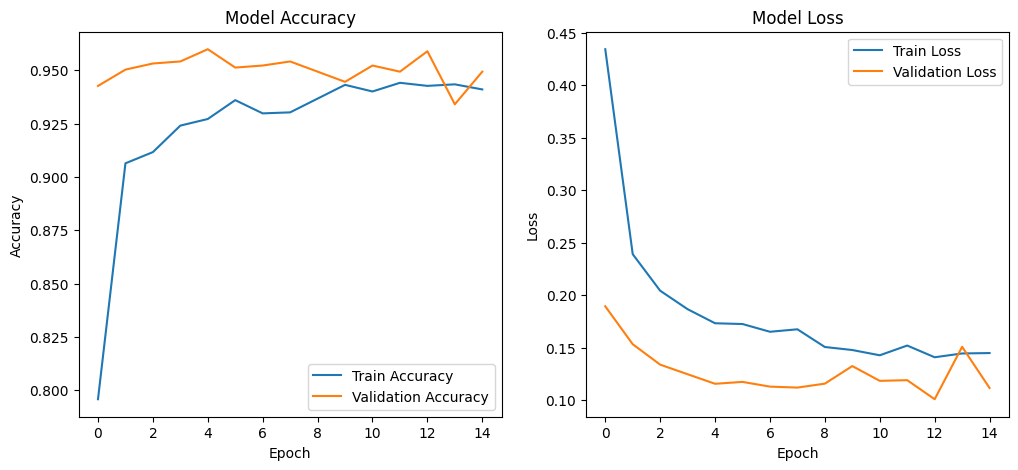

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

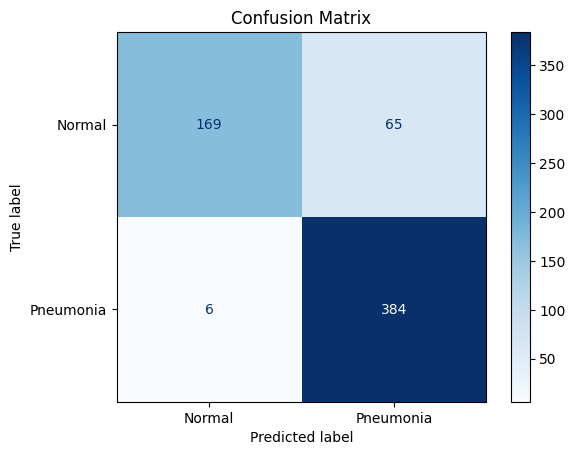

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pneumonia"]
).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


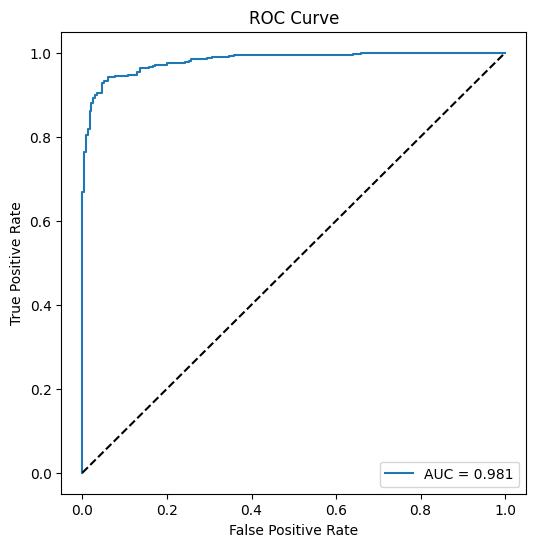

AUC: 0.9814924391847468


In [30]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(test_ds).ravel()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [31]:
model.save("best_pneumonia_model.keras")

In [32]:
from tensorflow.keras.models import load_model

test_model = load_model("best_pneumonia_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [33]:
from tensorflow.keras.models import load_model

model = load_model("best_pneumonia_model.keras")
model.save("best_pneumonia_model_v2.keras")